In [ ]:
import html
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from matplotlib import style
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split

style.use('ggplot')

SEED = 42

eda_stop_words = set(STOPWORDS) - {
    'not', 'no', 'nor', 'never'
}


Đọc dữ liệu từ csv

In [ ]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape

(50000, 2)

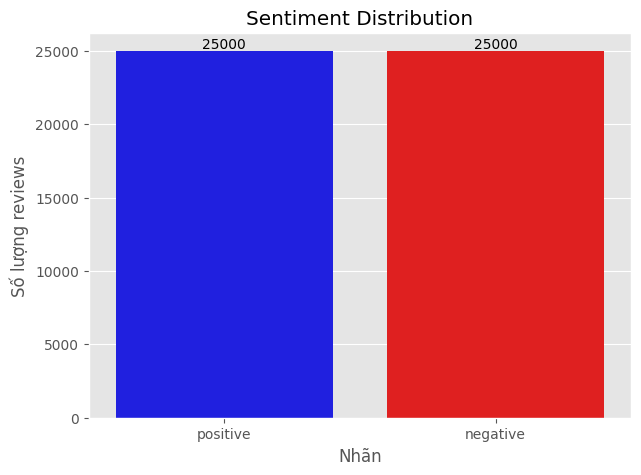

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x='sentiment',
    data=df,
    hue='sentiment',
    palette={
        'positive': 'blue',
        'negative': 'red'
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Sentiment Distribution")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng reviews")
plt.show()

In [ ]:
for i in range(min(5, len(df))):
    print(f"Review #{i + 1}:")
    print(df['review'].iloc[i], "\n")
    print("Sentiment:", df['sentiment'].iloc[i], "\n")

Review #1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [ ]:
#Hàm đếm từ
def no_of_words(text):
    return len(str(text).split())



In [ ]:
df['word count'] = df['review'].apply(no_of_words)

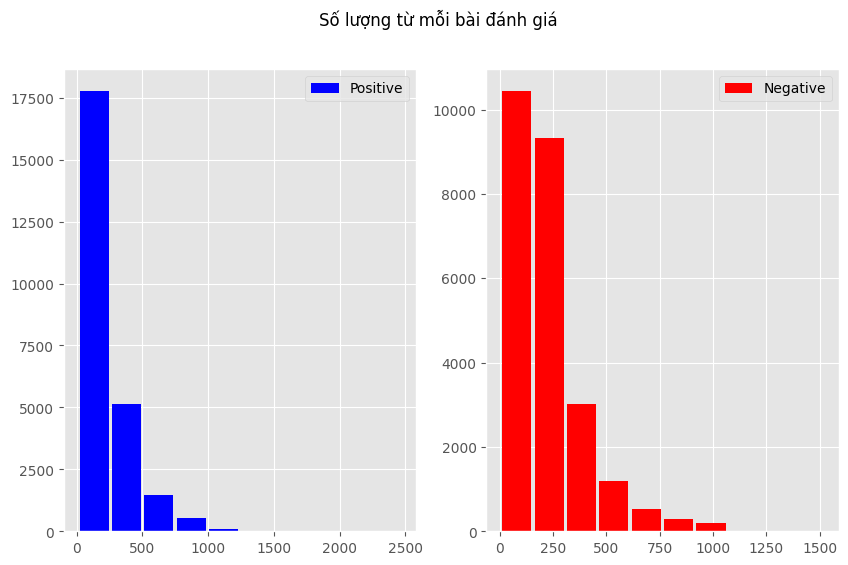

In [ ]:
#Sự phân bố bài đánh giá

fig,ax = plt.subplots(1,2, figsize=(10,6))
ax[0].hist(df[df['sentiment'] == 'positive']['word count'], label='Positive', color="blue", rwidth=0.9 );
ax[0].legend(loc='upper right');
ax[1].hist(df[df['sentiment'] == 'negative']['word count'], label='Negative', color="red", rwidth=0.9 );
ax[1].legend(loc='upper right');

fig.suptitle("Số lượng từ mỗi bài đánh giá")
plt.show()

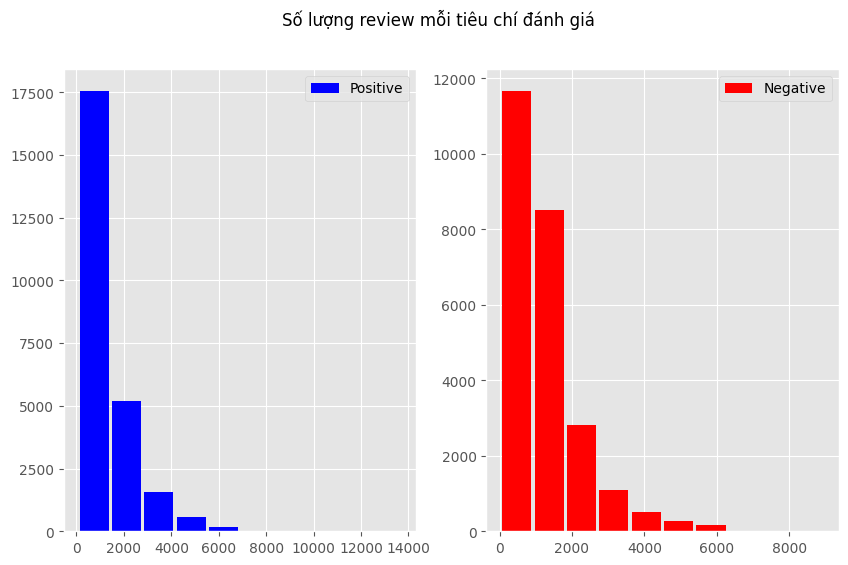

In [ ]:
fig,ax = plt.subplots(1,2, figsize=(10,6))
ax[0].hist(df[df['sentiment'] == 'positive']['review'].str.len(), label='Positive', color='blue', rwidth=0.9);
ax[0].legend(loc='upper right');
ax[1].hist(df[df['sentiment'] == 'negative']['review'].str.len(), label='Negative', color='red', rwidth=0.9);
ax[1].legend(loc='upper right');

fig.suptitle("Số lượng review mỗi tiêu chí đánh giá")
plt.show()

In [ ]:
#Chuyển nhãn thành số
df = df.dropna(subset=['review', 'sentiment']).copy()

df['sentiment'] = (
    df['sentiment']
    .astype(str)
    .str.strip()
    .str.lower()
)

df = df[df['sentiment'].isin(['positive', 'negative'])].copy()

df['label'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
}).astype('int32')

In [ ]:
df.head()

,review,sentiment,word count,label
0,One of the other reviewers has mentioned that ...,positive,307,1
1,A wonderful little production. <br /><br />The...,positive,162,1
2,I thought this was a wonderful way to spend ti...,positive,166,1
3,Basically there's a family where a little boy ...,negative,138,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1


In [ ]:

#Xử lý các review
def data_processing(text):
    text = html.unescape(str(text))
    text = text.lower()

    # Xóa các biến thể của <br>
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)

    # Xóa URL
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ', text
    )

    # Giữ chữ, số, khoảng trắng và dấu nháy đơn
    text = re.sub( r"[^a-z0-9\s']",' ',text)

    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()

    return text




In [ ]:
df['clean_review'] = df['review'].apply(
    data_processing
)

df = df[df['clean_review'].str.len() > 0 ].copy()

df[['review', 'clean_review', 'sentiment', 'label']].head()

,review,clean_review,sentiment,label
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive,1
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei's love in the time of money is a...,positive,1


In [ ]:
#Các bài bị trùng
duplicated_count = df.duplicated(
    subset=["clean_review", "label"]
).sum()

print("Số review trùng trước khi xóa:", duplicated_count)

#Xoá những bài bị trùng
df = (
    df.drop_duplicates(
        subset=["clean_review", "label"],
        keep="first"
    )
    .reset_index(drop=True)
)

print("Kích thước sau khi xóa trùng:", df.shape)

Số review trùng trước khi xóa: 423
Kích thước sau khi xóa trùng: (49577, 5)


In [ ]:
df['word_count'] = df['clean_review'].apply(no_of_words)

df['character_count'] = df['clean_review'].str.len()

df.head()

,review,sentiment,word count,label,clean_review,word_count,character_count
0,One of the other reviewers has mentioned that ...,positive,307,1,one of the other reviewers has mentioned that ...,308,1678
1,A wonderful little production. <br /><br />The...,positive,162,1,a wonderful little production the filming tech...,158,943
2,I thought this was a wonderful way to spend ti...,positive,166,1,i thought this was a wonderful way to spend ti...,165,880
3,Basically there's a family where a little boy ...,negative,138,0,basically there's a family where a little boy ...,132,691
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1,petter mattei's love in the time of money is a...,225,1243


In [ ]:
pos_reviews = df[df['label'] ==1] #chọn ra các positive review
pos_reviews.head()

,review,sentiment,word count,label,clean_review,word_count,character_count
0,One of the other reviewers has mentioned that ...,positive,307,1,one of the other reviewers has mentioned that ...,308,1678
1,A wonderful little production. <br /><br />The...,positive,162,1,a wonderful little production the filming tech...,158,943
2,I thought this was a wonderful way to spend ti...,positive,166,1,i thought this was a wonderful way to spend ti...,165,880
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1,petter mattei's love in the time of money is a...,225,1243
5,"Probably my all-time favorite movie, a story o...",positive,119,1,probably my all time favorite movie a story of...,121,635


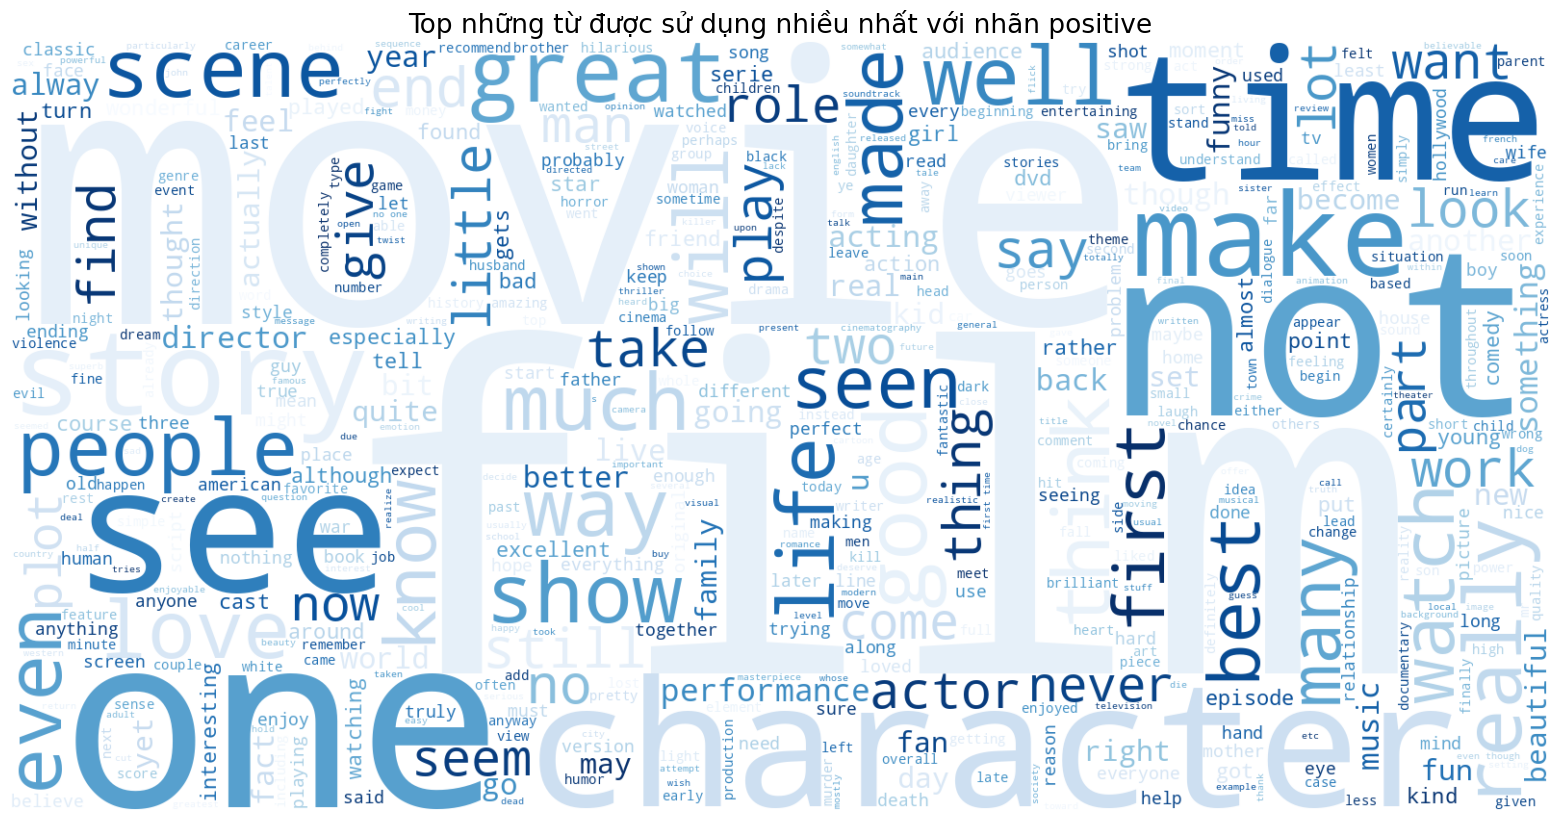

In [ ]:
positive_sample = pos_reviews[
    'clean_review'
].sample(
    n=min(5000, len(pos_reviews)),
    random_state=SEED
)

text = ' '.join(positive_sample)

plt.figure(
    figsize=(20, 10),
    facecolor='white'
)

wordcloud = WordCloud(
    max_words=500,
    width=1600,
    height=800,
    background_color='white',
    stopwords=eda_stop_words,
    colormap='Blues',
    random_state=SEED
).generate(text)

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis("off")

plt.title(
    'Top những từ được sử dụng nhiều nhất với nhãn positive',
    fontsize=19
)

plt.show()

In [ ]:
#đếm ra các từ thường được sử dụng
positive_count = Counter()

for review_text in pos_reviews['clean_review'].values:
    for word in review_text.split():
        if word not in eda_stop_words:
            positive_count[word] += 1

positive_count.most_common(15)


[('film', 40863),
 ('movie', 37263),
 ('not', 28189),
 ('one', 26894),
 ('good', 14925),
 ('great', 12873),
 ('story', 12798),
 ('well', 12679),
 ('time', 12665),
 ('see', 12196),
 ('really', 10703),
 ('will', 10218),
 ('even', 9571),
 ('first', 9179),
 ('no', 9178)]

In [ ]:
pos_words = pd.DataFrame(
    positive_count.most_common(15),
    columns=["word", "count"]
)
pos_words.columns = ['word', 'count']
pos_words.head()

,word,count
0,film,40863
1,movie,37263
2,not,28189
3,one,26894
4,good,14925


In [ ]:
px.bar(pos_words, x='count', y='word', title='', color='word')

In [ ]:
from operator import neg
#các nhãn negative
neg_reviews = df[df['label'] == 0]
neg_reviews.head()

,review,sentiment,word count,label,clean_review,word_count,character_count
3,Basically there's a family where a little boy ...,negative,138,0,basically there's a family where a little boy ...,132,691
7,"This show was an amazing, fresh & innovative i...",negative,174,0,this show was an amazing fresh innovative idea...,173,902
8,Encouraged by the positive comments about this...,negative,130,0,encouraged by the positive comments about this...,126,647
10,Phil the Alien is one of those quirky films wh...,negative,96,0,phil the alien is one of those quirky films wh...,92,524
11,I saw this movie when I was about 12 when it c...,negative,180,0,i saw this movie when i was about 12 when it c...,179,897


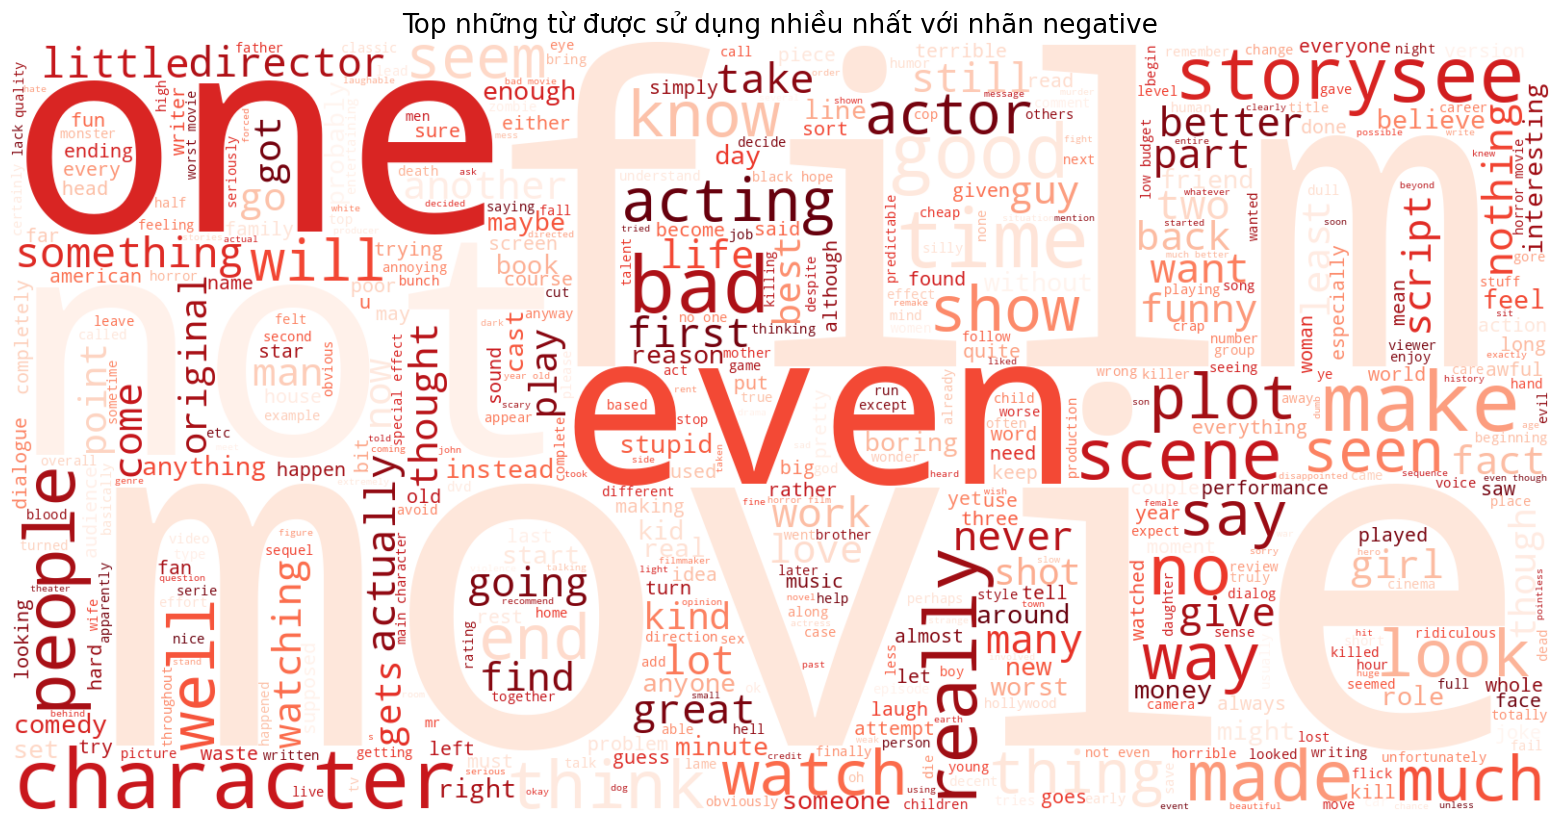

In [ ]:
negative_sample = neg_reviews[
    'clean_review'
].sample(
    n=min(5000, len(neg_reviews)),
    random_state=SEED
)

text = ' '.join(negative_sample)

plt.figure(
    figsize=(20, 10),
    facecolor='white'
)

wordcloud = WordCloud(
    max_words=500,
    width=1600,
    height=800,
    background_color='white',
    stopwords=eda_stop_words,
    colormap='Reds',
    random_state=SEED
).generate(text)

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis("off")

plt.title(
    'Top những từ được sử dụng nhiều nhất với nhãn negative',
    fontsize=19
)

plt.show()

In [ ]:
negative_count = Counter()

for review_text in neg_reviews[
    'clean_review'
].values:
    for word in review_text.split():
        if word not in eda_stop_words:
            negative_count[word] += 1

negative_count.most_common(15)

[('movie', 49110),
 ('film', 36282),
 ('not', 32051),
 ('one', 25752),
 ('no', 15871),
 ('even', 15093),
 ('good', 14520),
 ('bad', 14505),
 ('really', 12214),
 ('time', 12171),
 ('see', 10582),
 ('story', 10016),
 ('much', 9971),
 ('make', 9258),
 ('people', 9166)]

In [ ]:
neg_words = pd.DataFrame(
    negative_count.most_common(15),
    columns=["word", "count"]
)
px.bar(neg_words, x='count', y='word', title='Common words in negative reviews', color='word')

In [ ]:
#Chia tập dữ liệu
X = df['clean_review'].copy()
y = df['label'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49577,)
y shape: (49577,)


In [ ]:
#Lấy 70% train
x_train, x_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

In [ ]:
#Chia x_temp thành 15% validation và 15% test:
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)


x_train = x_train.reset_index(drop=True)
x_val = x_val.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
print(
    "Size of x_train:",
    x_train.shape
)

print("Size of y_train:",y_train.shape)

print("Size of x_val:", x_val.shape)

print("Size of y_val:",y_val.shape)

print("Size of x_test:",x_test.shape)

print("Size of y_test:", y_test.shape)

assert len(x_train) == len(y_train)
assert len(x_val) == len(y_val)
assert len(x_test) == len(y_test)

Size of x_train: (34703,)
Size of y_train: (34703,)
Size of x_val: (7437,)
Size of y_val: (7437,)
Size of x_test: (7437,)
Size of y_test: (7437,)


**XUẤT DỮ LIỆU ĐÃ LÀM**

In [ ]:
train_df = pd.DataFrame({'clean_review': x_train,'label': y_train})

validation_df = pd.DataFrame({'clean_review': x_val,'label': y_val})

test_df = pd.DataFrame({'clean_review': x_test,'label': y_test})

In [ ]:
from pathlib import Path

OUTPUT_DIR = Path("data_splits")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(
    OUTPUT_DIR / "train.csv",
    index=False
)

validation_df.to_csv(
    OUTPUT_DIR / "validation.csv",
    index=False
)

test_df.to_csv(
    OUTPUT_DIR / "test.csv",
    index=False
)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (34703, 2)
Validation: (7437, 2)
Test: (7437, 2)


**Kết thúc phần làm sạch dữ liệu và chia dữ liệu**

Chọn ra model muốn làm và ghi tên bên cạnh

CNN, RNN, Transformer. Sử dụng 3 file csv test, train và validation
